# Exploratory: S1 / S2 DiD results

- **GTP** 2026-08-10
- **Goal:** explore serialized S1 (event study) and S2 (static TWFE DiD) estimates, plus BSTS first-stage context, after outcomes are in hand
- **Inputs:** `results/estimates/*.json` (+ dynamic parquet), `data/processed/panel_station_week.parquet`, `config/treatment.yaml`

**This notebook is EXPLORATORY and post-outcome.** It is not pre-registered. Nothing here changes a registered specification without a Section 12 deviations-log entry marked `Results observed? Yes`.

**No figure in this notebook is a report figure.** Anything promoted goes into `src/cpca/plots/` and regenerates via `make estimates`.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

def _find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "config" / "treatment.yaml").exists():
            return cand
    # Fallback when the kernel cwd is notebooks/
    nb_parent = Path("..").resolve()
    if (nb_parent / "config" / "treatment.yaml").exists():
        return nb_parent
    raise FileNotFoundError("Could not locate repo root with config/treatment.yaml")


ROOT = _find_root()
sys.path.insert(0, str(ROOT / "src"))

from cpca.estimators.base import load_estimate
from cpca.plots import style as plot_style

plot_style.apply_theme()

with open(ROOT / "config" / "treatment.yaml") as f:
    TREATMENT = yaml.safe_load(f)

T0 = pd.Timestamp(TREATMENT["treatment"]["t0"])
FARE = pd.Timestamp(TREATMENT["treatment"]["fare_change_date"])
DID_PRE = pd.Timestamp(TREATMENT["sample_windows"]["did_pre_start"])
PRE_END = pd.Timestamp(TREATMENT["sample_windows"]["pre_end"])
WASHOUT = (
    pd.Timestamp(TREATMENT["sample_windows"]["washout_start"]),
    pd.Timestamp(TREATMENT["sample_windows"]["washout_end"]),
)
POST_END = pd.Timestamp(TREATMENT["sample_windows"]["post_end"])
EST_DIR = ROOT / "results" / "estimates"
PANEL_PATH = ROOT / "data" / "processed" / "panel_station_week.parquet"

print("ROOT", ROOT)
print("estimates dir", EST_DIR, "exists", EST_DIR.exists())


ROOT /Users/geoffperrin/Desktop/data_science/congestion_pricing_causal_analysis
estimates dir /Users/geoffperrin/Desktop/data_science/congestion_pricing_causal_analysis/results/estimates exists True


## 1. Load and inventory

Cross-estimator comparison table in embryo (RQ4). Estimates only - no re-fitting.


In [2]:
def inventory_estimates(est_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(est_dir.glob("*.json")):
        est = load_estimate(path)
        spec = est.spec or {}
        diag = est.diagnostics or {}
        rows.append(
            {
                "stem": path.stem,
                "estimator": est.estimator,
                "outcome": est.outcome,
                "treated_zone": spec.get("treated_zone") or diag.get("treated_zone"),
                "station_trends": spec.get("station_trends", diag.get("station_trends")),
                "att": est.att,
                "ci_low": est.ci_low,
                "ci_high": est.ci_high,
                "inference": est.inference,
                "placebo": bool(spec.get("placebo") or diag.get("placebo")),
                "reference_rel_month": spec.get("reference_rel_month")
                or diag.get("reference_rel_month"),
                "joint_wald_pvalue": diag.get("joint_wald_pvalue"),
                "path": str(path.name),
            }
        )
    return pd.DataFrame(rows).sort_values(["estimator", "outcome", "treated_zone"])


inv = inventory_estimates(EST_DIR)
print(f"{len(inv)} estimate JSON files")
inv


16 estimate JSON files


,stem,estimator,outcome,treated_zone,station_trends,att,ci_low,ci_high,inference,placebo,reference_rel_month,joint_wald_pvalue,path
0,bsts_bt_manhattan_entries,bsts,bt_manhattan_entries,NaN,None,-0.052546,-0.452425,0.351541,bayesian_ci,False,NaN,NaN,bsts_bt_manhattan_entries.json
1,bsts_log_bt_manhattan_entries,bsts,log_bt_manhattan_entries,NaN,None,-0.004406,-0.038163,0.029721,bayesian_ci,False,NaN,NaN,bsts_log_bt_manhattan_entries.json
4,event_study_did_crz_log_weekday_peak_entries,event_study_did,log_weekday_peak_entries,crz,True,-0.173860,-0.385786,0.038066,cluster_se,False,-8.0,6.204182e-18,event_study_did_crz_log_weekday_peak_entries.json
5,event_study_did_crz_log_weekend_entries,event_study_did,log_weekend_entries,crz,True,-0.115452,-1.036997,0.806093,cluster_se,False,-8.0,2.403406e-01,event_study_did_crz_log_weekend_entries.json
2,event_study_did_border_log_weekly_entries,event_study_did,log_weekly_entries,border,True,-0.203531,-0.577792,0.170731,cluster_se,False,-8.0,7.976007e-05,event_study_did_border_log_weekly_entries.json
3,event_study_did_border_log_weekly_entries_no_t...,event_study_did,log_weekly_entries,border,False,-0.036057,-0.072987,0.000873,cluster_se,False,-8.0,7.197601e-06,event_study_did_border_log_weekly_entries_no_t...
6,event_study_did_crz_log_weekly_entries,event_study_did,log_weekly_entries,crz,True,-0.244352,-0.438573,-0.050131,cluster_se,False,-8.0,5.801413e-15,event_study_did_crz_log_weekly_entries.json
7,event_study_did_crz_log_weekly_entries_no_trends,event_study_did,log_weekly_entries,crz,False,0.001670,-0.025698,0.029038,cluster_se,False,-8.0,3.648912e-13,event_study_did_crz_log_weekly_entries_no_tren...
12,twfe_did_crz_log_weekday_peak_entries,twfe_did,log_weekday_peak_entries,crz,True,0.010528,-0.060642,0.081697,cluster_se,False,NaN,NaN,twfe_did_crz_log_weekday_peak_entries.json
13,twfe_did_crz_log_weekend_entries,twfe_did,log_weekend_entries,crz,True,-0.131635,-0.335778,0.072509,cluster_se,False,NaN,NaN,twfe_did_crz_log_weekend_entries.json


In [3]:
# Focused S1/S2 / placebo / BSTS view
focus = inv[
    inv["estimator"].isin(
        ["event_study_did", "twfe_did", "twfe_did_placebo", "bsts"]
    )
].copy()
focus["att_pct"] = (np.expm1(focus["att"]) * 100).where(
    focus["outcome"].astype(str).str.startswith("log_")
)
display_cols = [
    "estimator",
    "outcome",
    "treated_zone",
    "station_trends",
    "placebo",
    "att",
    "ci_low",
    "ci_high",
    "att_pct",
    "joint_wald_pvalue",
]
focus[display_cols]


,estimator,outcome,treated_zone,station_trends,placebo,att,ci_low,ci_high,att_pct,joint_wald_pvalue
0,bsts,bt_manhattan_entries,NaN,None,False,-0.052546,-0.452425,0.351541,NaN,NaN
1,bsts,log_bt_manhattan_entries,NaN,None,False,-0.004406,-0.038163,0.029721,-0.439663,NaN
4,event_study_did,log_weekday_peak_entries,crz,True,False,-0.173860,-0.385786,0.038066,-15.958557,6.204182e-18
5,event_study_did,log_weekend_entries,crz,True,False,-0.115452,-1.036997,0.806093,-10.903682,2.403406e-01
2,event_study_did,log_weekly_entries,border,True,False,-0.203531,-0.577792,0.170731,-18.415470,7.976007e-05
3,event_study_did,log_weekly_entries,border,False,False,-0.036057,-0.072987,0.000873,-3.541472,7.197601e-06
6,event_study_did,log_weekly_entries,crz,True,False,-0.244352,-0.438573,-0.050131,-21.678784,5.801413e-15
7,event_study_did,log_weekly_entries,crz,False,False,0.001670,-0.025698,0.029038,0.167148,3.648912e-13
12,twfe_did,log_weekday_peak_entries,crz,True,False,0.010528,-0.060642,0.081697,1.058334,NaN
13,twfe_did,log_weekend_entries,crz,True,False,-0.131635,-0.335778,0.072509,-12.333887,NaN


## 2. Event study coefficient plots

Overlay primary (`station_trends=True`) and unadjusted (`station_trends=False`) on the same axes so the Section 12 adjustment is visible rather than asserted.


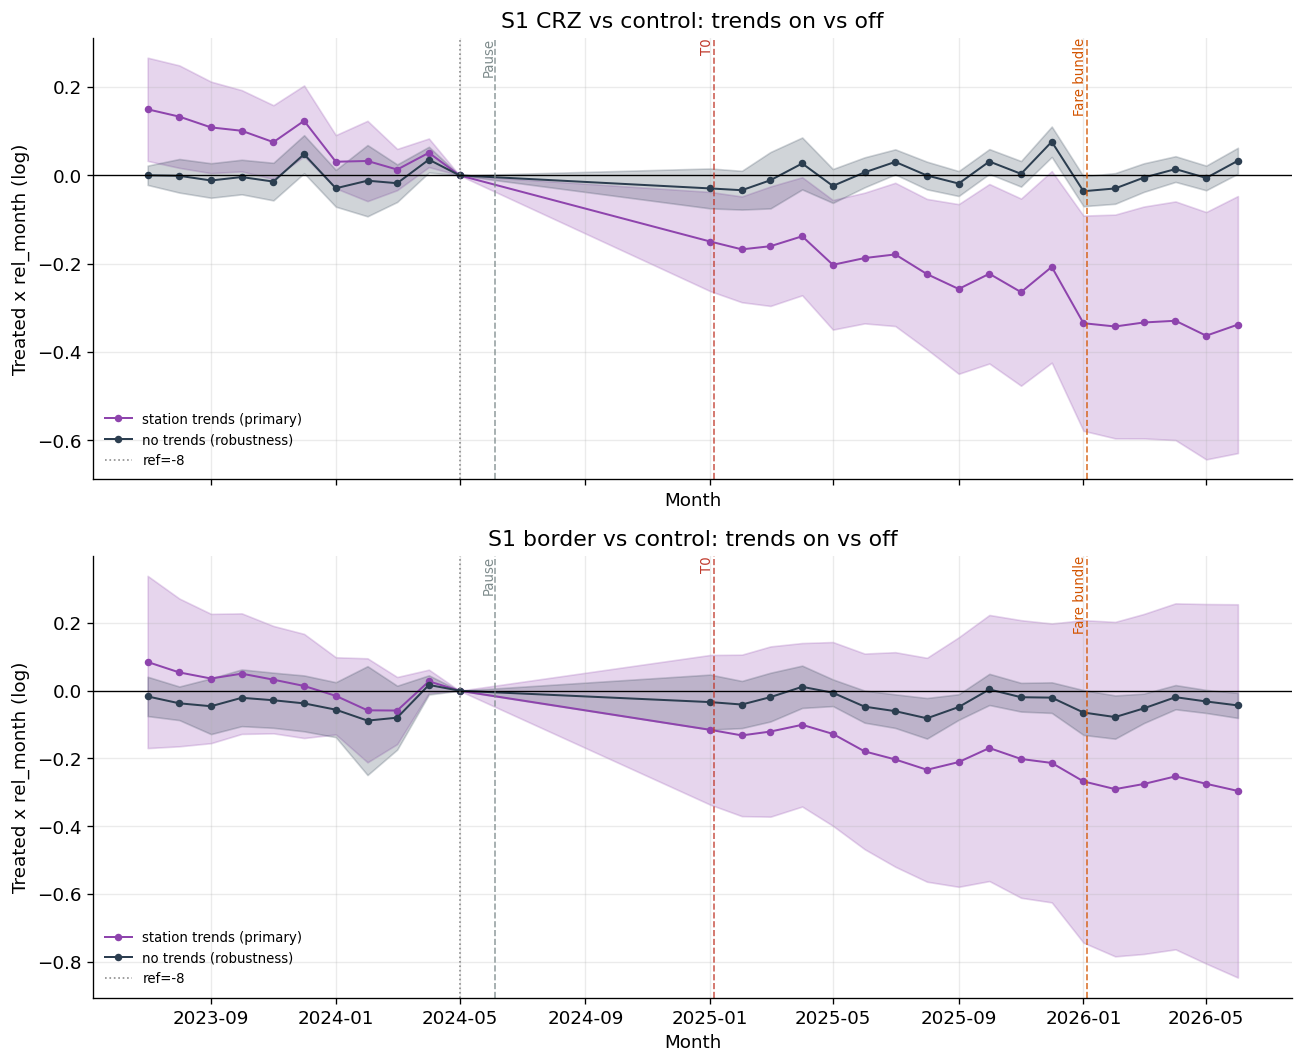

In [4]:
def rel_month_to_date(rel_month: int, t0: pd.Timestamp = T0) -> pd.Timestamp:
    return (t0.to_period("M") + int(rel_month)).to_timestamp()


def load_es(stem: str):
    return load_estimate(EST_DIR / f"{stem}.json")


def plot_event_overlay(
    ax,
    es_trends,
    es_no_trends,
    *,
    title: str,
):
    plot_style.apply_theme()
    for es, label, color in [
        (es_trends, "station trends (primary)", plot_style.COLORS["effect"]),
        (es_no_trends, "no trends (robustness)", plot_style.COLORS["control"]),
    ]:
        d = es.dynamic_effects.copy().sort_values("rel_month")
        d["month_start"] = d["rel_month"].map(rel_month_to_date)
        ax.fill_between(
            d["month_start"],
            d["ci_low"],
            d["ci_high"],
            color=color,
            alpha=0.22,
        )
        ax.plot(
            d["month_start"],
            d["coef"],
            color=color,
            marker="o",
            markersize=3.5,
            linewidth=1.2,
            label=label,
        )
    ref = int(
        es_trends.diagnostics.get("reference_rel_month")
        or es_trends.spec.get("reference_rel_month")
    )
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(
        rel_month_to_date(ref),
        color="0.55",
        linestyle=":",
        linewidth=1.0,
        label=f"ref={ref}",
    )
    plot_style.annotate_policy_dates(ax)
    ax.set_title(title)
    ax.set_ylabel("Treated x rel_month (log)")
    ax.set_xlabel("Month")
    ax.legend(frameon=False, loc="best", fontsize=8)


fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
plot_event_overlay(
    axes[0],
    load_es("event_study_did_crz_log_weekly_entries"),
    load_es("event_study_did_crz_log_weekly_entries_no_trends"),
    title="S1 CRZ vs control: trends on vs off",
)
plot_event_overlay(
    axes[1],
    load_es("event_study_did_border_log_weekly_entries"),
    load_es("event_study_did_border_log_weekly_entries_no_trends"),
    title="S1 border vs control: trends on vs off",
)
fig.tight_layout()
plt.show()


## 3. Pre-period leads, restricted window

Zoom to leads within the shortened `did_pre_start` window. Joint Wald below is the in-window Section 12 diagnostic from the serialized estimate, not a re-estimation.


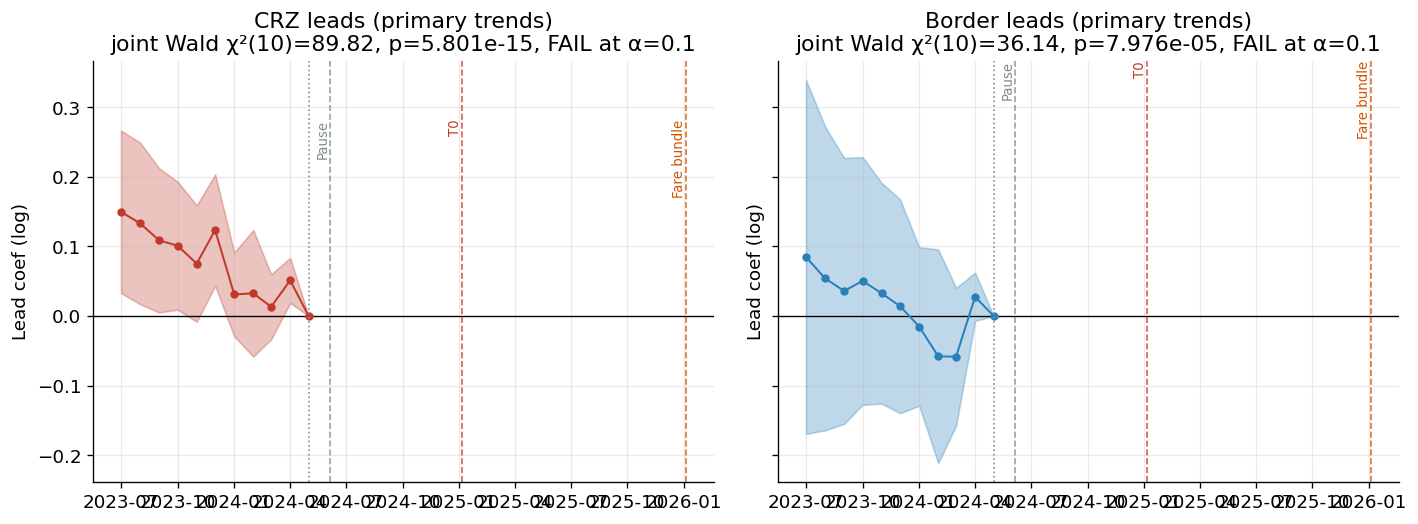

,contrast,ref,wald,df,p_joint,clears_alpha,did_pre_start
0,crz_vs_control,-8,89.824995,10,5.801413e-15,False,2023-07-01
1,border_vs_control,-8,36.136123,10,7.976007e-05,False,2023-07-01


In [5]:
def plot_leads(ax, es, *, title: str, color: str):
    d = es.dynamic_effects.copy()
    d = d[d["is_pre"]].sort_values("rel_month")
    d["month_start"] = d["rel_month"].map(rel_month_to_date)
    ref = int(
        es.diagnostics.get("reference_rel_month") or es.spec.get("reference_rel_month")
    )
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.fill_between(
        d["month_start"], d["ci_low"], d["ci_high"], color=color, alpha=0.3
    )
    ax.plot(
        d["month_start"],
        d["coef"],
        color=color,
        marker="o",
        markersize=4,
        linewidth=1.2,
    )
    ax.axvline(rel_month_to_date(ref), color="0.55", linestyle=":", linewidth=1.0)
    plot_style.annotate_policy_dates(ax)
    p = es.diagnostics.get("joint_wald_pvalue")
    w = es.diagnostics.get("joint_wald")
    dfw = es.diagnostics.get("joint_wald_df")
    alpha = es.diagnostics.get("joint_test_alpha", 0.10)
    clears = es.diagnostics.get("joint_test_clears_alpha")
    ax.set_title(
        f"{title}\n"
        f"joint Wald χ²({dfw})={w:.2f}, p={p:.4g}, "
        f"{'PASS' if clears else 'FAIL'} at α={alpha}"
    )
    ax.set_ylabel("Lead coef (log)")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
es_crz = load_es("event_study_did_crz_log_weekly_entries")
es_bor = load_es("event_study_did_border_log_weekly_entries")
plot_leads(axes[0], es_crz, title="CRZ leads (primary trends)", color=plot_style.COLORS["treated"])
plot_leads(axes[1], es_bor, title="Border leads (primary trends)", color=plot_style.COLORS["synthetic"])
fig.tight_layout()
plt.show()

lead_diag = pd.DataFrame(
    [
        {
            "contrast": "crz_vs_control",
            "ref": es_crz.diagnostics.get("reference_rel_month"),
            "wald": es_crz.diagnostics.get("joint_wald"),
            "df": es_crz.diagnostics.get("joint_wald_df"),
            "p_joint": es_crz.diagnostics.get("joint_wald_pvalue"),
            "clears_alpha": es_crz.diagnostics.get("joint_test_clears_alpha"),
            "did_pre_start": es_crz.diagnostics.get("did_pre_start"),
        },
        {
            "contrast": "border_vs_control",
            "ref": es_bor.diagnostics.get("reference_rel_month"),
            "wald": es_bor.diagnostics.get("joint_wald"),
            "df": es_bor.diagnostics.get("joint_wald_df"),
            "p_joint": es_bor.diagnostics.get("joint_wald_pvalue"),
            "clears_alpha": es_bor.diagnostics.get("joint_test_clears_alpha"),
            "did_pre_start": es_bor.diagnostics.get("did_pre_start"),
        },
    ]
)
lead_diag


## 4. Weekday peak vs weekend

Primary mechanism cut. Commuter mode substitution predicts effects concentrated in weekday peak. Comparable weekend effects would point away from commuting and need explaining, not explaining away.


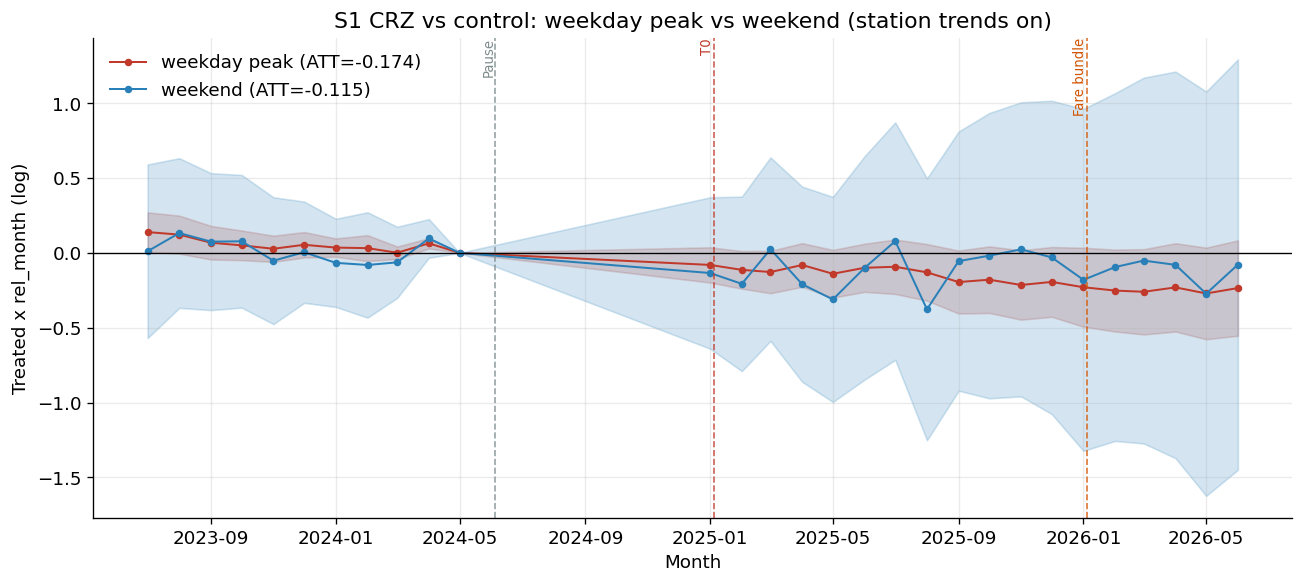

,outcome,att,ci_low,ci_high,joint_p
0,log_weekday_peak_entries,-0.173860,-0.385786,0.038066,6.204182e-18
1,log_weekend_entries,-0.115452,-1.036997,0.806093,2.403406e-01


In [6]:
es_peak = load_es("event_study_did_crz_log_weekday_peak_entries")
es_wknd = load_es("event_study_did_crz_log_weekend_entries")

fig, ax = plt.subplots(figsize=(11, 5))
for es, label, color in [
    (es_peak, "weekday peak", plot_style.COLORS["treated"]),
    (es_wknd, "weekend", plot_style.COLORS["synthetic"]),
]:
    d = es.dynamic_effects.copy().sort_values("rel_month")
    d["month_start"] = d["rel_month"].map(rel_month_to_date)
    ax.fill_between(d["month_start"], d["ci_low"], d["ci_high"], color=color, alpha=0.2)
    ax.plot(
        d["month_start"],
        d["coef"],
        color=color,
        marker="o",
        markersize=3.5,
        linewidth=1.2,
        label=f"{label} (ATT={es.att:.3f})",
    )
ax.axhline(0.0, color="black", linewidth=0.8)
plot_style.annotate_policy_dates(ax)
ax.set_title("S1 CRZ vs control: weekday peak vs weekend (station trends on)")
ax.set_ylabel("Treated x rel_month (log)")
ax.set_xlabel("Month")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "outcome": es_peak.outcome,
            "att": es_peak.att,
            "ci_low": es_peak.ci_low,
            "ci_high": es_peak.ci_high,
            "joint_p": es_peak.diagnostics.get("joint_wald_pvalue"),
        },
        {
            "outcome": es_wknd.outcome,
            "att": es_wknd.att,
            "ci_low": es_wknd.ci_low,
            "ci_high": es_wknd.ci_high,
            "joint_p": es_wknd.diagnostics.get("joint_wald_pvalue"),
        },
    ]
)


**Interpretation (mechanism).** Commuter mode substitution predicts larger (or clearer) effects in weekday peak than on weekends. If the two paths look similar, that is evidence for something other than peak commuting - tourism, discretionary trips, or composition change - and should be explained rather than explained away. These are serialized S1 paths; do not treat wide CIs as a license to prefer the friendlier outcome.


## 5. Distance-to-boundary heterogeneity

Descriptive station-level DiD by distance band (panel only - not a re-fit of S1/S2). Under H3 the expected pattern is diffuse, not a clean monotone gradient. Flatness is not failure; a sharp boundary gradient would suggest a local mechanism such as park-and-ride.


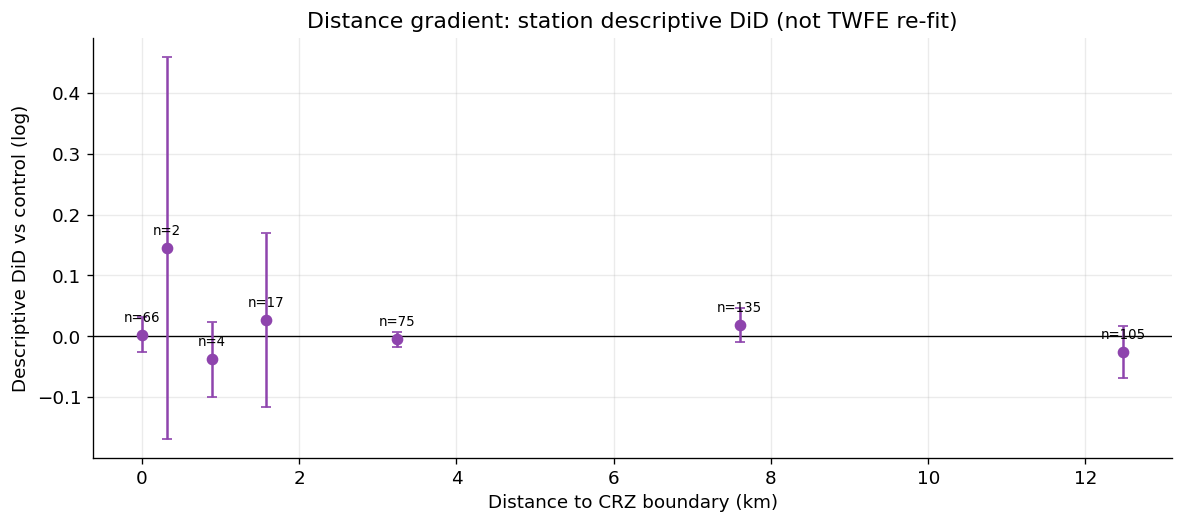

,band,x,n,mean,se,ci_low,ci_high
0,CRZ (0 km),0.000000,66,0.002660,0.014769,-0.026288,0.031607
1,0-0.5,0.318346,2,0.145683,0.160164,-0.168238,0.459604
2,0.5-1,0.889823,4,-0.037596,0.031437,-0.099212,0.024021
3,1-2,1.581421,17,0.026599,0.072659,-0.115813,0.169011
4,2-5,3.247091,75,-0.004789,0.006407,-0.017346,0.007768
5,5-10,7.603404,135,0.018788,0.014249,-0.009139,0.046715
6,10+,12.482324,105,-0.026610,0.021844,-0.069425,0.016205


In [7]:
panel = pd.read_parquet(PANEL_PATH)
panel["week_start"] = pd.to_datetime(panel["week_start"])
panel["station_complex_id"] = panel["station_complex_id"].astype(str)

# Same DiD window as S1/S2: did_pre_start..post_end, washout dropped, primary sample.
mask = (
    panel["primary_sample"]
    & (panel["week_start"] >= DID_PRE)
    & (panel["week_start"] <= POST_END)
    & ~(
        (panel["week_start"] >= WASHOUT[0]) & (panel["week_start"] <= WASHOUT[1])
    )
)
samp = panel.loc[mask].copy()
samp["post"] = samp["week_start"] >= T0

# Station-level descriptive DiD: (post - pre) minus control mean (post - pre).
station = (
    samp.groupby(["station_complex_id", "station_complex", "zone", "abs_dist_to_crz_boundary_km", "post"], as_index=False)[
        "log_weekly_entries"
    ]
    .mean()
)
wide = station.pivot_table(
    index=["station_complex_id", "station_complex", "zone", "abs_dist_to_crz_boundary_km"],
    columns="post",
    values="log_weekly_entries",
).reset_index()
wide = wide.rename(columns={False: "pre_mean", True: "post_mean"})
wide["delta"] = wide["post_mean"] - wide["pre_mean"]
ctrl_delta = wide.loc[wide["zone"] == "control", "delta"].mean()
wide["desc_effect"] = wide["delta"] - ctrl_delta

# Bins: CRZ at 0; border/control by distance.
crz = wide[wide["zone"] == "crz"].copy()
crz["band"] = "CRZ (0 km)"
crz["band_x"] = 0.0

other = wide[wide["zone"].isin(["border", "control"])].copy()
bins = [0, 0.5, 1, 2, 5, 10, 50]
labels = ["0-0.5", "0.5-1", "1-2", "2-5", "5-10", "10+"]
other["band"] = pd.cut(other["abs_dist_to_crz_boundary_km"], bins=bins, labels=labels, include_lowest=True)
other["band_x"] = other["abs_dist_to_crz_boundary_km"]

band_rows = []
# CRZ as single point
band_rows.append(
    {
        "band": "CRZ (0 km)",
        "x": 0.0,
        "n": len(crz),
        "mean": crz["desc_effect"].mean(),
        "se": crz["desc_effect"].sem(),
    }
)
for lab in labels:
    g = other[other["band"] == lab]
    if g.empty:
        continue
    band_rows.append(
        {
            "band": str(lab),
            "x": float(g["abs_dist_to_crz_boundary_km"].median()),
            "n": len(g),
            "mean": g["desc_effect"].mean(),
            "se": g["desc_effect"].sem(),
        }
    )
bands = pd.DataFrame(band_rows)
bands["ci_low"] = bands["mean"] - 1.96 * bands["se"]
bands["ci_high"] = bands["mean"] + 1.96 * bands["se"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axhline(0.0, color="black", linewidth=0.8)
ax.errorbar(
    bands["x"],
    bands["mean"],
    yerr=1.96 * bands["se"],
    fmt="o",
    color=plot_style.COLORS["effect"],
    capsize=3,
)
for _, r in bands.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r["x"], r["mean"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_xlabel("Distance to CRZ boundary (km)")
ax.set_ylabel("Descriptive DiD vs control (log)")
ax.set_title("Distance gradient: station descriptive DiD (not TWFE re-fit)")
fig.tight_layout()
plt.show()
bands


**Interpretation (H3).** A diffuse pattern across distance is consistent with origin-boarding of mode-shifted trips (entries-only data). A sharp jump right at the boundary would be a different story - local park-and-ride or zone-edge avoidance. Do not treat a flat gradient as a failed design.


## 6. Station-level effect distribution

Same descriptive station DiD as Section 5 (panel-based). Estimators do not currently serialize station-level TWFE residuals; promoting this figure would need that export in `src/`. Annotate notable top/bottom complexes by name.


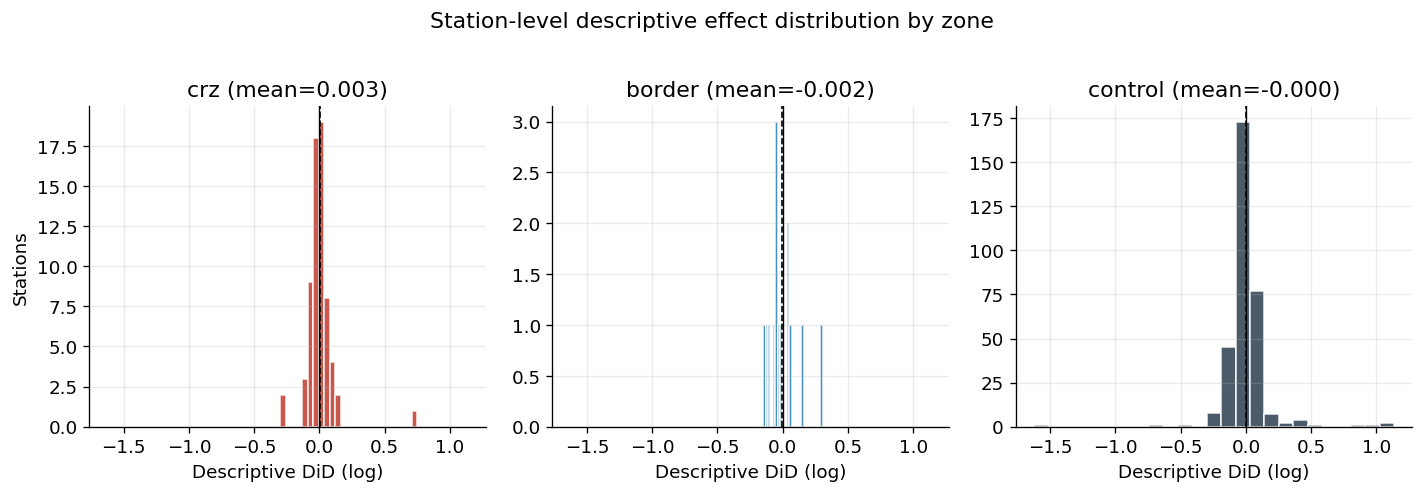

Top 15 CRZ by descriptive effect


post,station_complex_id,station_complex,desc_effect,abs_dist_to_crz_boundary_km,mechanism_note
95,224,57 St (F),0.751251,0.243787,
13,119,1 Av (L),0.137479,0.630498,
185,324,Houston St (1),0.135416,0.411457,
178,316,50 St (1),0.118792,0.724563,
55,168,"Spring St (C,E)",0.111008,0.571096,
1,10,"49 St (N,R,W)",0.109329,0.913668,
189,328,WTC Cortlandt (1),0.090202,0.133558,
186,325,Canal St (1),0.054593,0.406331,highway_approach
184,323,Christopher St-Sheridan Sq (1),0.052432,0.578056,
341,609,"Bryant Pk (B,D,F,M)/5 Av (7)",0.051854,1.312129,


Bottom 15 CRZ by descriptive effect


post,station_complex_id,station_complex,desc_effect,abs_dist_to_crz_boundary_km,mechanism_note
138,276,"5 Av/53 St (E,M)",-0.302213,0.542961,
403,TRAM1,RI Tramway (Manhattan),-0.291598,0.014169,
346,613,"Lexington Av (N,R,W)/59 St (4,5,6)",-0.120946,0.019414,
80,20,"City Hall (R,W)",-0.105306,0.296728,
267,414,"Bowling Green (4,5)",-0.098058,0.049629,
98,231,"Grand St (B,D)",-0.082186,0.919811,
100,234,East Broadway (F),-0.079998,0.370114,
382,8,"5 Av/59 St (N,R,W)",-0.068434,0.036329,
263,407,Astor Pl (6),-0.068060,1.432195,
356,622,"Brooklyn Bridge-City Hall (4,5,6)/Chambers St ...",-0.064694,0.149004,bridge_tunnel


In [8]:
# Keyword flags for mechanism annotation (name-based, exploratory).
KEYWORDS = {
    "rail_transfer": ("penn", "grand central", "times sq", "fulton", "atlantic", "jay st"),
    "highway_approach": ("canal", "holland", "lincoln", "battery", "fdr"),
    "bridge_tunnel": ("tunnel", "bridge", "roosevelt island", "york st"),
}


def annotate_mechanism(name: str) -> str:
    n = str(name).lower()
    hits = [k for k, words in KEYWORDS.items() if any(w in n for w in words)]
    return ", ".join(hits) if hits else ""


st = wide.copy()
st["mechanism_note"] = st["station_complex"].map(annotate_mechanism)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, zone, color in zip(
    axes,
    ["crz", "border", "control"],
    [plot_style.COLORS["treated"], plot_style.COLORS["synthetic"], plot_style.COLORS["control"]],
):
    g = st[st["zone"] == zone]["desc_effect"]
    ax.hist(g, bins=25, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0.0, color="black", linewidth=0.8)
    ax.axvline(g.mean(), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{zone} (mean={g.mean():.3f})")
    ax.set_xlabel("Descriptive DiD (log)")
axes[0].set_ylabel("Stations")
fig.suptitle("Station-level descriptive effect distribution by zone", y=1.02)
fig.tight_layout()
plt.show()

crz_st = st[st["zone"] == "crz"].sort_values("desc_effect")
top15 = crz_st.tail(15)[
    ["station_complex_id", "station_complex", "desc_effect", "abs_dist_to_crz_boundary_km", "mechanism_note"]
].iloc[::-1]
bot15 = crz_st.head(15)[
    ["station_complex_id", "station_complex", "desc_effect", "abs_dist_to_crz_boundary_km", "mechanism_note"]
]
print("Top 15 CRZ by descriptive effect")
display(top15)
print("Bottom 15 CRZ by descriptive effect")
display(bot15)


**Interpretation.** A broad shift and a few-station spike can share the same mean ATT and mean different things. Name annotations above are heuristic (string match on complex name) - treat as leads for map follow-up, not as identified mechanisms.


## 7. The causal chain in one figure

Top: BSTS into-Manhattan B&T crossings. Bottom: S1 CRZ subway event-study path. BSTS is interpreted primarily on 2025 data because the 2026-01-04 B&T toll hike contaminates later crossings; compare the reported relative ATT to the 11-13% MTA vehicle-entry benchmark in analysis plan Section 10. Divergence is a finding to explain, not an error.

Holiday / Christmas-New Year trough adjustment (Section 12, 2026-08-10) is now in the primary specs: S1/S2 drop holiday and Dec 24-Jan 2 trough weeks; BSTS includes holiday + winter_trough covariates and averages ATT on non-holiday/non-trough post days. Re-run `make estimates` before treating these charts as current.


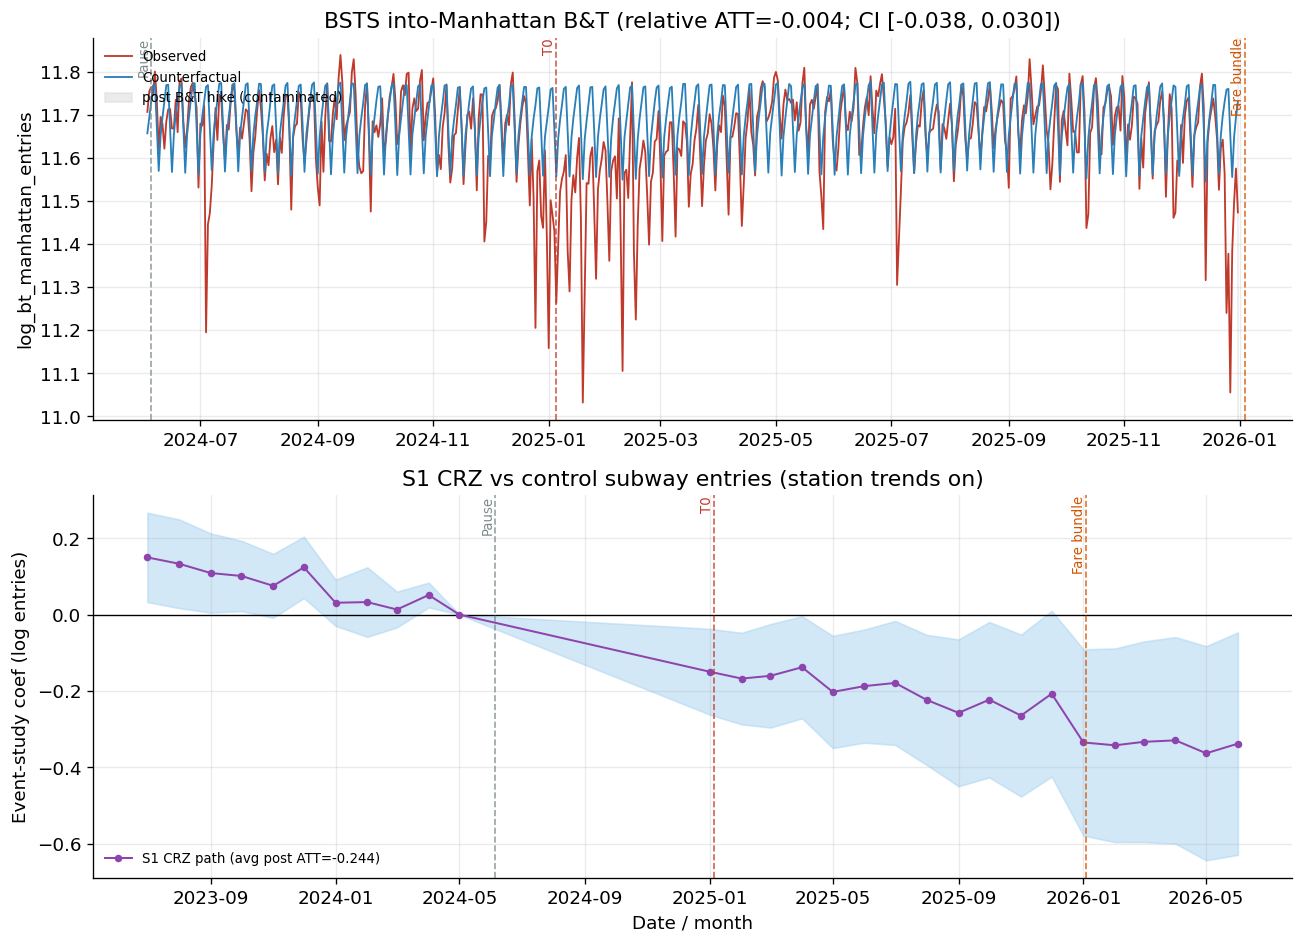

BSTS note: Primary first-stage uses into-Manhattan B&T crossings; CRZ vehicle entries lack pre-T0 coverage. CausalImpact library post window starts day after pre_end (includes washout for forecast continuity); reported ATT averages T0 onward only.
MTA vehicle-entry benchmark (plan §10): roughly 11-13% decline. BSTS relative ATT=-0.0044 (approx -0.4% if interpreted as log approx; library stores relative_att in diagnostics=-0.004406320552302204).


In [9]:
bsts = load_estimate(EST_DIR / "bsts_log_bt_manhattan_entries.json")
es = load_es("event_study_did_crz_log_weekly_entries")

dyn_b = bsts.dynamic_effects.copy()
dyn_b["date"] = pd.to_datetime(dyn_b["date"])
# Emphasize 2025 primary window visually
bsts_post_end = pd.Timestamp(TREATMENT.get("bsts", {}).get("post_end_primary", "2025-12-31"))

dyn_e = es.dynamic_effects.copy().sort_values("rel_month")
dyn_e["month_start"] = dyn_e["rel_month"].map(rel_month_to_date)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

ax0 = axes[0]
ax0.plot(dyn_b["date"], dyn_b["observed"], color=plot_style.COLORS["treated"], label="Observed", lw=1.1)
ax0.plot(
    dyn_b["date"],
    dyn_b["prediction"],
    color=plot_style.COLORS["counterfactual"],
    label="Counterfactual",
    lw=1.1,
)
ax0.axvspan(bsts_post_end, dyn_b["date"].max(), color="0.85", alpha=0.5, label="post B&T hike (contaminated)")
plot_style.annotate_policy_dates(ax0)
ax0.set_ylabel(bsts.outcome)
ax0.set_title(
    f"BSTS into-Manhattan B&T (relative ATT={bsts.att:.3f}; "
    f"CI [{bsts.ci_low:.3f}, {bsts.ci_high:.3f}])"
)
ax0.legend(frameon=False, loc="upper left", fontsize=8)

ax1 = axes[1]
ax1.axhline(0.0, color="black", linewidth=0.8)
ax1.fill_between(
    dyn_e["month_start"],
    dyn_e["ci_low"],
    dyn_e["ci_high"],
    color=plot_style.COLORS["ci"],
    alpha=0.55,
)
ax1.plot(
    dyn_e["month_start"],
    dyn_e["coef"],
    color=plot_style.COLORS["effect"],
    marker="o",
    markersize=3.5,
    lw=1.2,
    label=f"S1 CRZ path (avg post ATT={es.att:.3f})",
)
plot_style.annotate_policy_dates(ax1)
ax1.set_ylabel("Event-study coef (log entries)")
ax1.set_xlabel("Date / month")
ax1.set_title("S1 CRZ vs control subway entries (station trends on)")
ax1.legend(frameon=False, loc="best", fontsize=8)

fig.tight_layout()
plt.show()

print(
    "BSTS note:",
    (bsts.diagnostics or {}).get("note"),
)
print(
    "MTA vehicle-entry benchmark (plan §10): roughly 11-13% decline. "
    f"BSTS relative ATT={bsts.att:.4f} "
    f"(approx {100 * bsts.att:.1f}% if interpreted as log approx; "
    f"library stores relative_att in diagnostics="
    f"{(bsts.diagnostics or {}).get('relative_att')})."
)


## 8. Influence and leave-one-out

No station-level TWFE residuals are serialized yet, so this leave-one-out uses the **descriptive** CRZ station effects from Section 5/6: drop each CRZ complex and recompute the mean descriptive effect. Flag complexes that move the mean by more than 0.005 log points. This is influence diagnostics for the descriptive distribution, not a re-fit of S1.


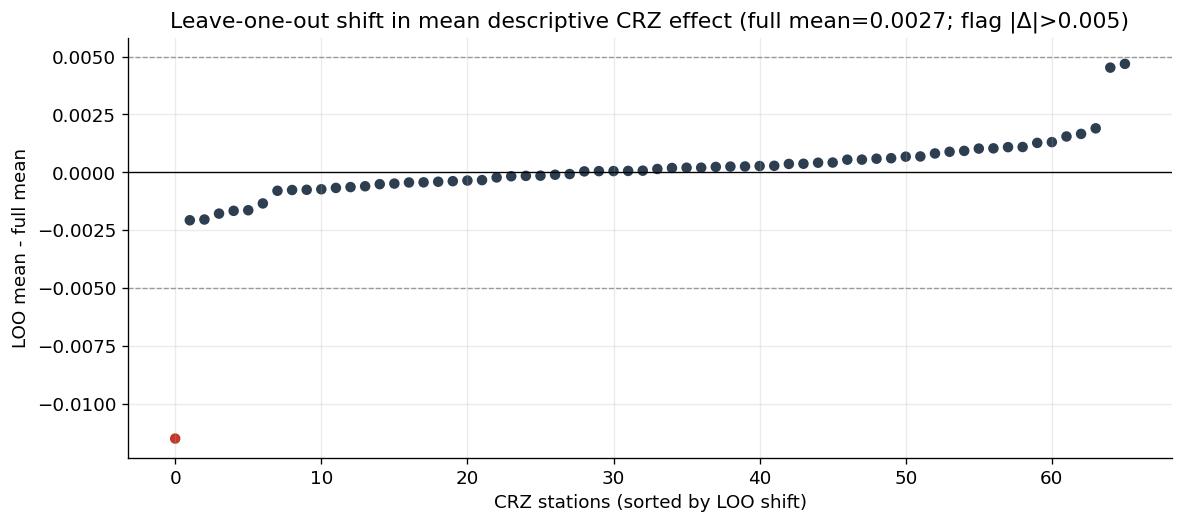

Flagged stations: 1 / 66


,station_complex_id,station_complex,station_effect,loo_mean,delta_vs_full,flag
17,224,57 St (F),0.751251,-0.008857,-0.011517,True


In [10]:
crz_effects = st.loc[st["zone"] == "crz", ["station_complex_id", "station_complex", "desc_effect"]].copy()
base_mean = crz_effects["desc_effect"].mean()
threshold = 0.005

loo_rows = []
for sid, row in crz_effects.set_index("station_complex_id").iterrows():
    loo = crz_effects.loc[crz_effects["station_complex_id"] != sid, "desc_effect"].mean()
    loo_rows.append(
        {
            "station_complex_id": sid,
            "station_complex": row["station_complex"],
            "station_effect": row["desc_effect"],
            "loo_mean": loo,
            "delta_vs_full": loo - base_mean,
        }
    )
loo = pd.DataFrame(loo_rows).sort_values("delta_vs_full")
loo["flag"] = loo["delta_vs_full"].abs() > threshold

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axhline(threshold, color="0.6", linestyle="--", lw=0.8)
ax.axhline(-threshold, color="0.6", linestyle="--", lw=0.8)
colors = np.where(loo["flag"], plot_style.COLORS["treated"], plot_style.COLORS["control"])
ax.scatter(range(len(loo)), loo["delta_vs_full"], c=colors, s=28)
ax.set_title(
    f"Leave-one-out shift in mean descriptive CRZ effect "
    f"(full mean={base_mean:.4f}; flag |Δ|>{threshold})"
)
ax.set_xlabel("CRZ stations (sorted by LOO shift)")
ax.set_ylabel("LOO mean - full mean")
fig.tight_layout()
plt.show()

print(f"Flagged stations: {int(loo['flag'].sum())} / {len(loo)}")
loo.loc[loo["flag"]].sort_values("delta_vs_full", key=np.abs, ascending=False).head(20)


## 9. Verdict

What the mechanism evidence supports, what it does not, and candidate Section 12 rows (proposed only - do not edit the plan from this notebook).


### Supports
- Running the full estimator inventory side by side (RQ4 embryo): S1 vs S2, trends on vs off, CRZ vs border, BSTS first-stage.
- The trends on/off overlay is the honest display of why Section 12 added station-specific trends.
- Weekday-peak vs weekend S1 paths are available as a registered-style mechanism cut (serialized estimates, not hand ATT).
- Descriptive distance and station-level spreads are useful for H3 storytelling once residual export exists.

### Does not support (yet)
- Treating S1 average-of-lags ATT as interchangeable with S2 static ATT when they disagree - disagreement is an RQ4 result, not a bug to average away.
- Claiming the in-window joint Wald "passes" for CRZ/border primary specs - serialized diagnostics still reject at α=0.10 even on `did_pre_start`.
- Reading Sections 5/6/8 as TWFE residuals - they are panel descriptive DiDs until the estimator serializes station-level residuals.
- Reading BSTS post-2026-01-04 B&T levels as clean first-stage evidence.

### Candidate Section 12 rows (for human decision)
| Date | Section | Proposed change | Results observed? | Reason |
|---|---|---|---|---|
| 2026-08-10 | 6 | Optionally serialize station-level TWFE residuals / influence stats from S1/S2 for mechanism maps and LOO | Yes (post-outcome exploratory notebook) | Sections 6 and 8 of `notebooks/03_did_results.ipynb` currently use descriptive panel DiDs as a stand-in |
| 2026-08-10 | 6 / 8 | Add weekday-peak and weekend outcomes to the primary `make estimates` grid for S1/S2 (CRZ contrast) | Yes | Mechanism cut is informative and already runnable via CLI |
| 2026-08-10 | 6 | Record S1 vs S2 numerical disagreement on CRZ log weekly entries under station trends as an RQ4 exhibit rather than selecting one | Yes | Inventory table in this notebook |

No plan text was edited from this notebook.
